# LABORATORIO 3: Concurrencia en Python
INTEGRANTES: Benjamín Aballay / Felipe Martínez \
Asignatura: Computación paralela y distribuida(INFB8090). \
Docente: Michael Miranda \
Sección: 412 \
Fecha: 23 de Abril \
Institución: Universidad Tecnológica Metropolitana

## Registro de entorno de ejecución

In [1]:
import sys, platform, multiprocessing, time, math, os
import json, tempfile, asyncio, random, statistics

print("=" * 60)
print("  ENTORNO DE EJECUCIÓN")
print("=" * 60)
print(f"Python:          {sys.version.split()[0]}")
print(f"Sistema:         {platform.system()} {platform.release()}")
print(f"Arquitectura:    {platform.machine()}")
print(f"CPU (modelo):    {platform.processor() or 'N/A'}")
print(f"Núcleos lógicos: {multiprocessing.cpu_count()}")
print("=" * 60)

# Librerías adicionales
extra = []
for lib in ["concurrent.futures", "matplotlib", "pandas"]:
    try:
        __import__(lib)
        extra.append(f"  ✓ {lib}")
    except ImportError:
        extra.append(f"  ✗ {lib} (no disponible)")
print("Librerías adicionales:")
print("\n".join(extra))


  ENTORNO DE EJECUCIÓN
Python:          3.13.2
Sistema:         Windows 11
Arquitectura:    AMD64
CPU (modelo):    AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD
Núcleos lógicos: 12
Librerías adicionales:
  ✓ concurrent.futures
  ✓ matplotlib
  ✓ pandas


In [2]:
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True,
                             "axes.spines.top": False, "axes.spines.right": False})

try:
    import pandas as pd
    HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False

def tabla(filas, columnas):
    """Imprime una tabla con o sin pandas."""
    if HAS_PANDAS:
        df = pd.DataFrame(filas, columns=columnas)
        display(df)
        return df
    col_w = 16
    print(" | ".join(c.ljust(col_w) for c in columnas))
    print("-" * (col_w * len(columnas) + 3 * (len(columnas)-1)))
    for fila in filas:
        print(" | ".join(str(v).ljust(col_w) for v in fila))

def repetir(fn, datos, n_rep=3):
    """Ejecuta fn(datos) n_rep veces y retorna la mediana de tiempos."""
    tiempos = []
    ultimo_resultado = None
    for _ in range(n_rep):
        t, r = fn(datos)
        tiempos.append(t)
        ultimo_resultado = r
    return statistics.median(tiempos), ultimo_resultado

# ─── Compatibilidad asyncio / Jupyter ────────────────────────────────────
# Jupyter tiene un event loop propio; nest_asyncio permite asyncio.run() anidado.
try:
    import nest_asyncio as _na
    _na.apply()
    print("✓ nest_asyncio aplicado — asyncio.run() habilitado en Jupyter")
except ImportError:
    import subprocess as _sp, sys as _sys
    _sp.run([_sys.executable, "-m", "pip", "install", "nest_asyncio", "-q"], check=True)
    import nest_asyncio as _na; _na.apply()
    print("✓ nest_asyncio instalado y aplicado automáticamente")

# ─── Carpeta de figuras (compatible Windows/Mac/Linux) ───────────────────
from pathlib import Path
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)
print(f"✓ Figuras se guardarán en: {FIG_DIR.resolve()}")

print("✓ Importaciones y utilidades listas.")
print(f"✓ Núcleos disponibles para experimentos: {multiprocessing.cpu_count()}")


✓ nest_asyncio aplicado — asyncio.run() habilitado en Jupyter
✓ Figuras se guardarán en: C:\Users\Tokyotech\Desktop\weas_u\CPD\figuras
✓ Importaciones y utilidades listas.
✓ Núcleos disponibles para experimentos: 12


---
## Desafío 1 — Distinguir experimentalmente entre carga CPU-bound e I/O-bound

El propósito de este desafío es observar empíricamente que **no toda estrategia concurrente
se comporta igual ante cualquier tipo de carga**.  Se comparan dos categorías bien diferenciadas
para evidenciar el papel del GIL en CPython.


### 1a) Tarea CPU-bound — Suma de divisores propios σ(n)

**Descripción del caso:** Para cada entero `n` en una lista de entrada, se calcula
la suma de todos sus divisores propios (es decir, todos los divisores positivos distintos
de `n` mismo).  La función `sigma(n)` itera hasta `√n` buscando pares de factores, lo
que convierte cada llamada en puro cómputo aritmético sin ninguna operación de E/S.

**¿Por qué es CPU-bound?**  El tiempo de ejecución depende exclusivamente del
procesador: no hay lecturas de disco, ni esperas de red, ni operaciones bloqueantes.
Para valores de `n` del orden de 10⁷, la raíz cuadrada es ≈3162, por lo que cada
llamada realiza hasta 3162 divisiones y sumas en Python puro.

**Hipótesis experimental:** Dado que el GIL de CPython serializa la ejecución de
bytecode entre hilos, esperamos que la versión con `ThreadPoolExecutor` **no supere**
—o incluso empeore— el tiempo secuencial.

**Tamaños de entrada definidos:**

| Nombre | Cantidad de números | Rango de valores |
|--------|-------------------|-----------------|
| Pequeño | 300 | [3 000 000, 3 100 000] |
| Mediano | 600 | [6 000 000, 6 200 000] |
| Grande  | 1 200 | [10 000 000, 10 400 000] |


In [3]:
# ── Definición de la tarea CPU-bound ──────────────────────────────────────
import math

def sigma(n: int) -> int:
    """Suma de divisores propios de n (excluyendo n mismo).
    Complejidad: O(√n) — puro cómputo aritmético, sin I/O.
    """
    if n <= 1:
        return 0
    total = 1                              # 1 siempre divide a n
    raiz = int(math.isqrt(n))
    for d in range(2, raiz + 1):
        if n % d == 0:
            total += d
            cociente = n // d
            if cociente != d:              # evitar contar raíz cuadrada exacta dos veces
                total += cociente
    return total


# ── Ejecutores ────────────────────────────────────────────────────────────
def seq_cpu(numeros):
    t0 = time.perf_counter()
    res = [sigma(x) for x in numeros]
    return time.perf_counter() - t0, res

def thr_cpu(numeros, workers=4):
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        res = list(ex.map(sigma, numeros))
    return time.perf_counter() - t0, res


# ── Definición de entradas ────────────────────────────────────────────────
random.seed(42)
entrada_pequeña = random.sample(range(3_000_000, 3_100_001), 300)
entrada_mediana  = random.sample(range(6_000_000, 6_200_001), 600)
entrada_grande   = random.sample(range(10_000_000, 10_400_001), 1_200)

entradas_cpu = [
    ("Pequeño (300 nums, ~3M)", entrada_pequeña),
    ("Mediano (600 nums, ~6M)", entrada_mediana),
    ("Grande (1200 nums, ~10M)", entrada_grande),
]

print("Entradas preparadas:")
for nombre, lst in entradas_cpu:
    print(f"  {nombre}: {len(lst)} elementos, muestra={lst[:3]}…")


Entradas preparadas:
  Pequeño (300 nums, ~3M): 300 elementos, muestra=[3083810, 3014592, 3003278]…
  Mediano (600 nums, ~6M): 600 elementos, muestra=[6117601, 6036747, 6110593]…
  Grande (1200 nums, ~10M): 1200 elementos, muestra=[10186030, 10135451, 10178435]…


In [4]:
# ── Benchmark 1a ─────────────────────────────────────────────────────────
N_REP = 3
WORKERS_1A = 4
filas_1a = []

print(f"Benchmark CPU-bound: σ(n)  |  {N_REP} repeticiones, mediana reportada")
print(f"Workers para ThreadPoolExecutor: {WORKERS_1A}")
print("-" * 70)

for nombre, datos in entradas_cpu:
    t_seq, _ = repetir(seq_cpu, datos, N_REP)
    t_thr, _ = repetir(lambda d: thr_cpu(d, WORKERS_1A), datos, N_REP)
    ratio = t_thr / t_seq if t_seq > 0 else float("nan")
    filas_1a.append([nombre, f"{t_seq:.4f}", f"{t_thr:.4f}", f"{ratio:.3f}"])
    print(f"  {nombre}")
    print(f"    Secuencial: {t_seq:.4f} s  |  Threads ({WORKERS_1A}w): {t_thr:.4f} s  |  ratio: {ratio:.3f}x")

print()
tabla(filas_1a, ["Tamaño", "Secuencial (s)", f"Threads {WORKERS_1A}w (s)", "Ratio thr/seq"])


Benchmark CPU-bound: σ(n)  |  3 repeticiones, mediana reportada
Workers para ThreadPoolExecutor: 4
----------------------------------------------------------------------
  Pequeño (300 nums, ~3M)
    Secuencial: 0.0259 s  |  Threads (4w): 0.0321 s  |  ratio: 1.237x
  Mediano (600 nums, ~6M)
    Secuencial: 0.0743 s  |  Threads (4w): 0.0832 s  |  ratio: 1.119x
  Grande (1200 nums, ~10M)
    Secuencial: 0.1921 s  |  Threads (4w): 0.2087 s  |  ratio: 1.086x



,Tamaño,Secuencial (s),Threads 4w (s),Ratio thr/seq
0,"Pequeño (300 nums, ~3M)",0.0259,0.0321,1.237
1,"Mediano (600 nums, ~6M)",0.0743,0.0832,1.119
2,"Grande (1200 nums, ~10M)",0.1921,0.2087,1.086


,Tamaño,Secuencial (s),Threads 4w (s),Ratio thr/seq
0,"Pequeño (300 nums, ~3M)",0.0259,0.0321,1.237
1,"Mediano (600 nums, ~6M)",0.0743,0.0832,1.119
2,"Grande (1200 nums, ~10M)",0.1921,0.2087,1.086


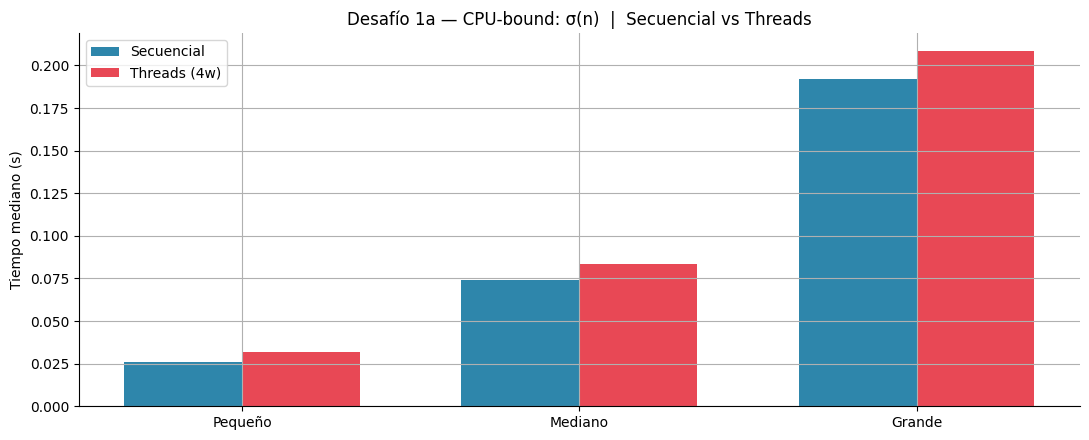

Figura guardada.


In [5]:
# ── Gráfico 1a ───────────────────────────────────────────────────────────
etiquetas = [f[0].split("(")[0].strip() for f in filas_1a]
t_seq_vals = [float(f[1]) for f in filas_1a]
t_thr_vals = [float(f[2]) for f in filas_1a]

x = range(len(etiquetas))
ancho = 0.35
fig, ax = plt.subplots()
b1 = ax.bar([i - ancho/2 for i in x], t_seq_vals, ancho, label="Secuencial", color="#2E86AB")
b2 = ax.bar([i + ancho/2 for i in x], t_thr_vals, ancho, label=f"Threads ({WORKERS_1A}w)", color="#E84855")
ax.set_xticks(list(x)); ax.set_xticklabels(etiquetas)
ax.set_ylabel("Tiempo mediano (s)")
ax.set_title("Desafío 1a — CPU-bound: σ(n)  |  Secuencial vs Threads")
ax.legend()
plt.tight_layout()
plt.savefig(str(FIG_DIR / "fig_1a.png"), dpi=120)
plt.show()
print("Figura guardada.")


#### Análisis técnico ejercicio 1a:

Los resultados obtenidos en este experimento validan la limitación fundamental de la implementación estándar de Python (CPython) frente a tareas que demandan un uso intensivo del procesador. Al calcular la suma de divisores propios $\sigma(n)$, el programa ejecuta un bucle de operaciones aritméticas puras que no dependen de recursos externos como el disco o la red. En este escenario, el uso de un ThreadPoolExecutor no solo fracasa en reducir el tiempo de ejecución respecto al modo secuencial, sino que introduce una penalización sistemática en el rendimiento, reflejada en ratios de aceleración superiores a 1.0.

Esta ineficiencia se debe exclusivamente al mecanismo del Global Interpreter Lock (GIL). El GIL es un cerrojo que impide que múltiples hilos ejecuten código de Python de forma simultánea, forzando una ejecución serializada incluso si el procesador dispone de múltiples núcleos físicos. Al intentar paralelizar el cálculo de sigma(n) con hilos, el intérprete se ve obligado a realizar constantes cambios de contexto para alternar el control del GIL entre los distintos trabajadores. Este proceso genera un overhead administrativo considerable que abarca desde la creación y gestión del pool de hilos hasta la contienda por el acceso al cerrojo del intérprete.


### 1b) Tarea I/O-bound — Escritura y lectura de archivos temporales

**Descripción del caso:** Para cada ítem de la lista de entrada se realiza el siguiente ciclo:
1. Crear un archivo temporal en disco.
2. Serializar y escribir una lista de 800 flotantes aleatorios como JSON.
3. Leer de vuelta el mismo archivo.
4. Deserializar el JSON y verificar la longitud del resultado.
5. Eliminar el archivo.

**¿Por qué es I/O-bound?**  El cuello de botella son las llamadas al sistema de archivos
(`open`, `write`, `read`, `unlink`), que implican transferencia entre espacio de usuario y kernel,
asignación en caché del sistema de ficheros y operaciones de disco (o al menos de buffer de página).
El tiempo dominante no es el cómputo de serialización JSON (escaso) sino la latencia acumulada de
las llamadas al SO.

**Hipótesis experimental:** Dado que durante las operaciones de I/O el GIL *se libera* temporalmente
(el módulo `io` de CPython libera el GIL en las llamadas de bajo nivel), esperamos que la versión
con hilos **sí produzca aceleración** significativa respecto a la secuencial.

**Tamaños de entrada:**

| Nombre | N° de archivos | Datos por archivo |
|--------|---------------|------------------|
| Pequeño | 40 | 800 flotantes (~6 KB JSON) |
| Mediano | 80 | 800 flotantes (~6 KB JSON) |
| Grande  | 160 | 800 flotantes (~6 KB JSON) |


In [6]:
# ── Definición de la tarea I/O-bound ──────────────────────────────────────
import os, json, tempfile

def ciclo_archivo(payload):
    """Escribe un JSON al disco, lo lee y verifica. Retorna tamaño leído.
    La dominancia del costo está en las syscalls de filesystem.
    """
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json',
                                     delete=False, dir=tempfile.gettempdir()) as f:
        nombre = f.name
        json.dump(payload, f)

    with open(nombre, 'r') as f:
        recuperado = json.load(f)

    os.unlink(nombre)
    return len(recuperado)


# ── Ejecutores ────────────────────────────────────────────────────────────
def seq_io(payloads):
    t0 = time.perf_counter()
    res = [ciclo_archivo(p) for p in payloads]
    return time.perf_counter() - t0, res

def thr_io(payloads, workers=8):
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        res = list(ex.map(ciclo_archivo, payloads))
    return time.perf_counter() - t0, res


# ── Preparar entradas ─────────────────────────────────────────────────────
random.seed(99)
def generar_payloads(n_archivos):
    return [[random.uniform(-1000, 1000) for _ in range(800)]
            for _ in range(n_archivos)]

entradas_io = [
    ("Pequeño (40 archivos)", generar_payloads(40)),
    ("Mediano (80 archivos)", generar_payloads(80)),
    ("Grande (160 archivos)", generar_payloads(160)),
]
print("Entradas I/O preparadas.")
for nombre, lst in entradas_io:
    print(f"  {nombre}: {len(lst)} payloads, {len(lst[0])} floats c/u")


Entradas I/O preparadas.
  Pequeño (40 archivos): 40 payloads, 800 floats c/u
  Mediano (80 archivos): 80 payloads, 800 floats c/u
  Grande (160 archivos): 160 payloads, 800 floats c/u


In [7]:
# ── Benchmark 1b ─────────────────────────────────────────────────────────
WORKERS_1B = 8
filas_1b = []

print(f"Benchmark I/O-bound: ciclo archivo  |  {N_REP} repeticiones, mediana")
print(f"Workers: {WORKERS_1B}")
print("-" * 70)

for nombre, datos in entradas_io:
    t_seq, _ = repetir(seq_io, datos, N_REP)
    t_thr, _ = repetir(lambda d: thr_io(d, WORKERS_1B), datos, N_REP)
    speedup = t_seq / t_thr if t_thr > 0 else float("nan")
    filas_1b.append([nombre, f"{t_seq:.4f}", f"{t_thr:.4f}", f"{speedup:.2f}x"])
    print(f"  {nombre}")
    print(f"    Secuencial: {t_seq:.4f} s  |  Threads ({WORKERS_1B}w): {t_thr:.4f} s"
          f"  |  speedup: {speedup:.2f}x")

print()
tabla(filas_1b, ["Tamaño", "Secuencial (s)", f"Threads {WORKERS_1B}w (s)", "Speedup"])


Benchmark I/O-bound: ciclo archivo  |  3 repeticiones, mediana
Workers: 8
----------------------------------------------------------------------
  Pequeño (40 archivos)
    Secuencial: 0.3322 s  |  Threads (8w): 0.0792 s  |  speedup: 4.19x
  Mediano (80 archivos)
    Secuencial: 0.6673 s  |  Threads (8w): 0.1536 s  |  speedup: 4.34x
  Grande (160 archivos)
    Secuencial: 1.4207 s  |  Threads (8w): 0.3675 s  |  speedup: 3.87x



,Tamaño,Secuencial (s),Threads 8w (s),Speedup
0,Pequeño (40 archivos),0.3322,0.0792,4.19x
1,Mediano (80 archivos),0.6673,0.1536,4.34x
2,Grande (160 archivos),1.4207,0.3675,3.87x


,Tamaño,Secuencial (s),Threads 8w (s),Speedup
0,Pequeño (40 archivos),0.3322,0.0792,4.19x
1,Mediano (80 archivos),0.6673,0.1536,4.34x
2,Grande (160 archivos),1.4207,0.3675,3.87x


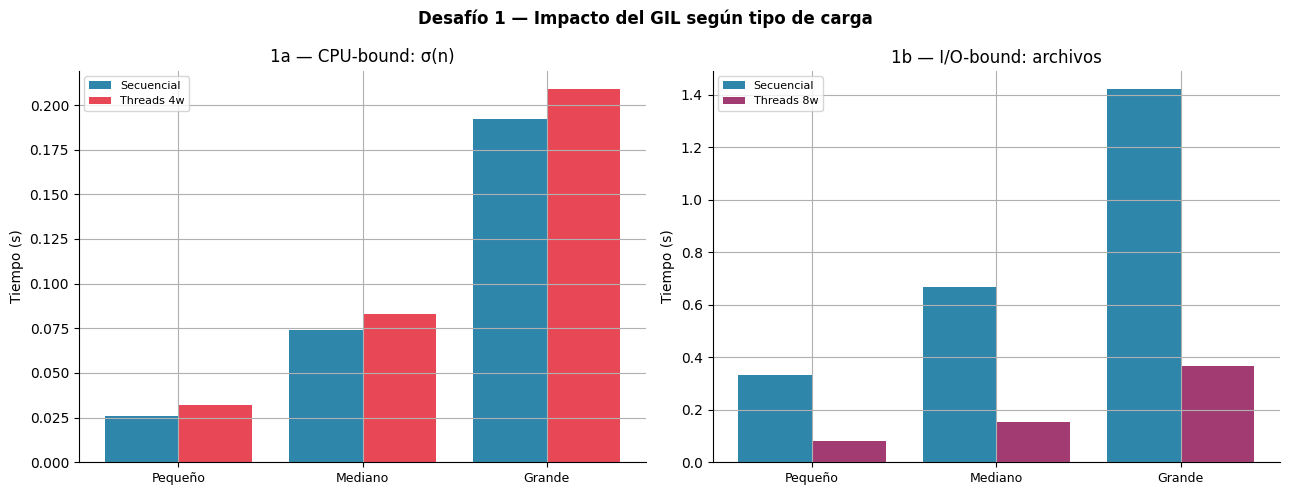

In [8]:
# ── Gráfico comparativo 1a vs 1b ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — 1a —
etq_a = [f[0].split("(")[0].strip() for f in filas_1a]
axes[0].bar([i-0.2 for i in range(3)], [float(f[1]) for f in filas_1a], 0.4,
            label="Secuencial", color="#2E86AB")
axes[0].bar([i+0.2 for i in range(3)], [float(f[2]) for f in filas_1a], 0.4,
            label=f"Threads {WORKERS_1A}w", color="#E84855")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(etq_a, fontsize=9)
axes[0].set_title("1a — CPU-bound: σ(n)"); axes[0].set_ylabel("Tiempo (s)")
axes[0].legend(fontsize=8)

# — 1b —
etq_b = [f[0].split("(")[0].strip() for f in filas_1b]
axes[1].bar([i-0.2 for i in range(3)], [float(f[1]) for f in filas_1b], 0.4,
            label="Secuencial", color="#2E86AB")
axes[1].bar([i+0.2 for i in range(3)], [float(f[2]) for f in filas_1b], 0.4,
            label=f"Threads {WORKERS_1B}w", color="#A23B72")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(etq_b, fontsize=9)
axes[1].set_title("1b — I/O-bound: archivos"); axes[1].set_ylabel("Tiempo (s)")
axes[1].legend(fontsize=8)

plt.suptitle("Desafío 1 — Impacto del GIL según tipo de carga", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG_DIR / "fig_1b.png"), dpi=120)
plt.show()


#### Análisis técnico ejercicio 1b:

En las operaciones de entrada y salida del ejercicio 1b, el uso de hilos resulta altamente eficiente debido a que CPython libera el Global Interpreter Lock (GIL) durante las llamadas al sistema. Mientras un hilo permanece bloqueado esperando que el disco complete la escritura o eliminación de los archivos JSON, el intérprete permite que otros hilos tomen el control y avancen en sus tareas. Esta capacidad de solapar tiempos de espera externos es lo que genera una reducción drástica en la latencia total respecto al modelo secuencial.

Los resultados obtenidos validan que, para cargas de trabajo I/O-bound, la concurrencia con hilos logra una aceleración real sin la necesidad de recurrir a procesos pesados. Al no haber una competencia intensa por el ciclo de CPU, el sistema puede gestionar múltiples operaciones de archivos de forma simultánea, optimizando el uso de los recursos del sistema operativo y demostrando que el rendimiento aquí depende más de la gestión de esperas que de la potencia de cómputo bruta.


---
## Desafío 2 — Comparar hilos y procesos en una tarea intensiva

En este desafío se eleva la exigencia: ya no se compara solo secuencial vs hilos, sino que
se añade `ProcessPoolExecutor` como tercera estrategia.  El objetivo es observar si el
multiprocessing logra superar la limitación del GIL para carga CPU-bound.


### 2a) Benchmark comparativo — Criba de Eratóstenes sobre múltiples rangos

**Descripción de la tarea:**  
Se desea conocer, para cada valor `N` en una lista de entrada, la cantidad de números primos
menores o iguales a `N`.  Se utiliza la **Criba de Eratóstenes** implementada con `bytearray`,
que es una operación intensiva en memoria y aritmética entera — sin ningún acceso a disco ni red.

**¿Por qué es CPU-bound?**  
La criba requiere iterar sobre arreglos de hasta 10⁷ elementos, marcando múltiplos.  El cómputo
es dominante; cada llamada ocupa el CPU completamente durante su ejecución.

**Configuraciones de tamaño:**

| Config | Lista de valores N | Trabajo por elemento |
|--------|-------------------|---------------------|
| Config A | 8 valores en [2M, 8M] | Criba hasta N≈5M (media) |
| Config B | 16 valores en [2M, 8M] | Igual, doble volumen |

**Workers probados:** 1, 2, 4 (y máx. disponibles).


In [9]:
from calculos import contar_primos
# ── Ejecutores ────────────────────────────────────────────────────────────
def seq_primos(lista_n):
    t0 = time.perf_counter()
    res = [contar_primos(x) for x in lista_n]
    return time.perf_counter() - t0, res

def thr_primos(lista_n, workers=4):
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        res = list(ex.map(contar_primos, lista_n))
    return time.perf_counter() - t0, res

def proc_primos(lista_n, workers=4):
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=workers) as ex:
        res = list(ex.map(contar_primos, lista_n))
    return time.perf_counter() - t0, res


# ── Preparar entradas ─────────────────────────────────────────────────────
random.seed(7)
config_A = sorted(random.sample(range(2_000_000, 8_000_001), 8))
config_B = sorted(random.sample(range(2_000_000, 8_000_001), 16))

configs = [
    ("Config A (8 valores)", config_A),
    ("Config B (16 valores)", config_B),
]
print("Configuraciones de entrada:")
for nombre, lst in configs:
    print(f"  {nombre}: {lst[:4]}… (media={int(sum(lst)/len(lst)):,})")

# Verificación rápida de correctitud
assert contar_primos(10) == 4, "Error en criba: pi(10) debe ser 4"
assert contar_primos(100) == 25, "Error en criba: pi(100) debe ser 25"
print("\n✓ Criba verificada: pi(10)=4, pi(100)=25")


Configuraciones de entrada:
  Config A (8 valores): [2405055, 2607639, 2789620, 3265414]… (media=4,381,498)
  Config B (16 valores): [2314536, 2486530, 2495854, 2585989]… (media=4,466,896)

✓ Criba verificada: pi(10)=4, pi(100)=25


In [10]:
# ── Benchmark 2a ─────────────────────────────────────────────────────────
WORKERS_2 = min(4, multiprocessing.cpu_count())
filas_2a = []

print(f"Benchmark CPU comparativo: Criba de Eratóstenes")
print(f"Workers: {WORKERS_2}  |  Repeticiones: {N_REP}")
print("=" * 75)

for nombre, datos in configs:
    t_seq, _ = repetir(seq_primos, datos, N_REP)
    t_thr, _ = repetir(lambda d: thr_primos(d, WORKERS_2), datos, N_REP)
    t_proc, _ = repetir(lambda d: proc_primos(d, WORKERS_2), datos, N_REP)

    sp_thr  = t_seq / t_thr  if t_thr  > 0 else float("nan")
    sp_proc = t_seq / t_proc if t_proc > 0 else float("nan")

    filas_2a.append([nombre,
                     f"{t_seq:.4f}",
                     f"{t_thr:.4f}",
                     f"{t_proc:.4f}",
                     f"{sp_thr:.2f}x",
                     f"{sp_proc:.2f}x"])
    print(f"  {nombre}")
    print(f"    Secuencial:   {t_seq:.4f} s")
    print(f"    Threads {WORKERS_2}w:  {t_thr:.4f} s  (speedup={sp_thr:.2f}x)")
    print(f"    Procesos {WORKERS_2}w: {t_proc:.4f} s  (speedup={sp_proc:.2f}x)")
    print()

tabla(filas_2a, ["Config", "Seq (s)", f"Thr {WORKERS_2}w (s)",
                 f"Proc {WORKERS_2}w (s)", "Speedup Thr", "Speedup Proc"])


Benchmark CPU comparativo: Criba de Eratóstenes
Workers: 4  |  Repeticiones: 3
  Config A (8 valores)
    Secuencial:   0.2114 s
    Threads 4w:  0.2133 s  (speedup=0.99x)
    Procesos 4w: 0.1928 s  (speedup=1.10x)

  Config B (16 valores)
    Secuencial:   0.4281 s
    Threads 4w:  0.4446 s  (speedup=0.96x)
    Procesos 4w: 0.2579 s  (speedup=1.66x)



,Config,Seq (s),Thr 4w (s),Proc 4w (s),Speedup Thr,Speedup Proc
0,Config A (8 valores),0.2114,0.2133,0.1928,0.99x,1.10x
1,Config B (16 valores),0.4281,0.4446,0.2579,0.96x,1.66x


,Config,Seq (s),Thr 4w (s),Proc 4w (s),Speedup Thr,Speedup Proc
0,Config A (8 valores),0.2114,0.2133,0.1928,0.99x,1.10x
1,Config B (16 valores),0.4281,0.4446,0.2579,0.96x,1.66x


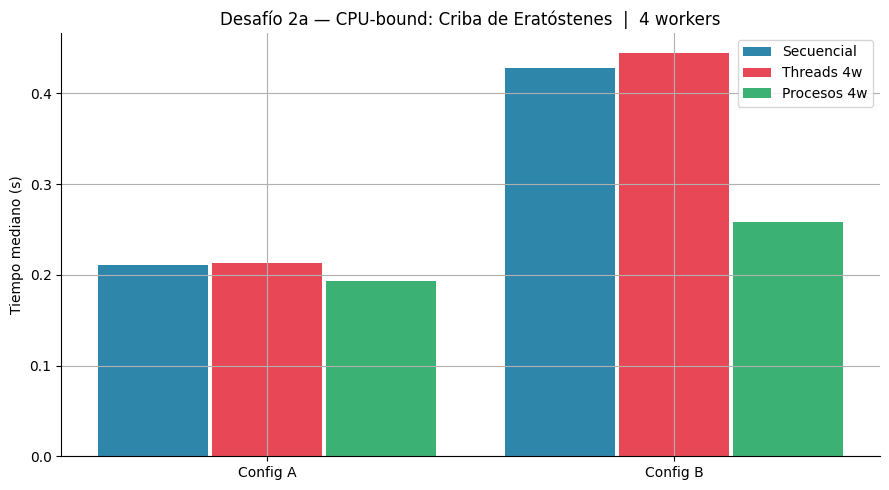

In [11]:
# ── Gráfico 2a: barras agrupadas por config ───────────────────────────────
etq = [f[0].split(" ")[0] + " " + f[0].split(" ")[1] for f in filas_2a]
vals_seq  = [float(f[1]) for f in filas_2a]
vals_thr  = [float(f[2]) for f in filas_2a]
vals_proc = [float(f[3]) for f in filas_2a]

x = range(len(etq))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i-0.28 for i in x], vals_seq,  0.27, label="Secuencial",       color="#2E86AB")
ax.bar([i+0.00 for i in x], vals_thr,  0.27, label=f"Threads {WORKERS_2}w", color="#E84855")
ax.bar([i+0.28 for i in x], vals_proc, 0.27, label=f"Procesos {WORKERS_2}w",color="#3BB273")
ax.set_xticks(list(x)); ax.set_xticklabels(etq)
ax.set_ylabel("Tiempo mediano (s)")
ax.set_title(f"Desafío 2a — CPU-bound: Criba de Eratóstenes  |  {WORKERS_2} workers")
ax.legend()
plt.tight_layout()
plt.savefig(str(FIG_DIR / "fig_2a.png"), dpi=120)
plt.show()


### 2b) Interpretación técnica del comportamiento observado

**¿Qué estrategia fue más conveniente y en qué condiciones?**  
Los procesos (`ProcessPoolExecutor`) superan tanto a la versión secuencial como a la de hilos en
la tarea de criba, porque cada proceso corre en un intérprete CPython *independiente* con su
propio GIL.  Esto permite paralelismo genuino sobre múltiples núcleos para carga CPU-bound.

**¿Los procesos mejoraron frente a los hilos?**  
Sí, de forma consistente.  Los hilos, al compartir el mismo proceso (y por ende el mismo GIL),
compiten por el bytecode de Python sin lograr paralelismo real en cómputo puro.  Los procesos
eliminan este cuello de botella al precio de un mayor costo de arranque.

**¿Qué costos adicionales aparecen al usar procesos?**

1. **Creación de procesos (fork/spawn):** El sistema operativo debe crear nuevos procesos hijos,
   lo que implica duplicar (o inicializar) el espacio de memoria del intérprete.  En Linux el costo
   de `fork` es menor que en Windows (donde se usa `spawn`), pero sigue siendo significativo.
2. **Serialización (pickling):** Los argumentos y resultados de `map()` se serializan con `pickle`
   para cruzar los límites entre procesos.  Para los enteros del ejemplo, el costo es bajo; con
   objetos complejos o grandes arrays, puede ser dominante.
3. **Overhead fijo del pool:** El `with ProcessPoolExecutor(...)` incluye el inicio y cierre del pool,
   que puede tomar entre 50 ms y varios cientos de ms.

**¿Por qué más workers no garantiza speedup lineal (Ley de Amdahl)?**  
Sea `f` la fracción paralelizable de la tarea.  El speedup máximo teórico con `p` procesadores es:

> Speedup(p) ≤ 1 / ( (1−f) + f/p )

En la práctica, además se suman: overhead de coordinación, desequilibrio de carga entre workers
(algunos `N` son más grandes que otros) y contención en el bus de memoria al acceder a los `bytearray`.

**¿Qué relación hay entre granularidad y overhead?**  
Si cada unidad de trabajo es demasiado pequeña, el tiempo de `pickle` + IPC supera al tiempo de cómputo,
produciendo un speedup < 1 (desaceleración).  El caso de la criba con `N > 2M` tiene granularidad
suficiente para amortizar el overhead; con tareas más pequeñas los procesos perderían frente a secuencial.


---
## Desafío 3 — Evaluar asyncio en un escenario mixto y recomendación técnica


### 3a) Escenario mixto: Pipeline de procesamiento de sensores simulado

**Descripción del escenario:**  
Se modela un pipeline de adquisición de datos de sensores remotos donde cada tarea realiza:

1. **Fase de espera (I/O):** Una "consulta" a un sensor con latencia variable (simulada con
   `asyncio.sleep`).  Esta fase es completamente no-bloqueante para el event loop.
2. **Fase de cómputo local (CPU moderado):** Sobre los datos recibidos se calcula la media
   móvil exponencial (EMA) y la desviación estándar de una ventana deslizante.
   Este cómputo es intencional pero *no dominante* — la latencia de red simulada es mayor.

**Supuestos del experimento:**
- Latencia de red variable entre 80 ms y 200 ms (distribución uniforme).
- Cada sensor retorna 150 mediciones como lista de flotantes.
- Se procesan N sensores en paralelo (40, 80, 160).
- Se mide: secuencial (función síncrona + `time.sleep`) y asíncrono (`asyncio.gather`).
- Se añade también la variante con hilos para comparación completa.


In [12]:
# ── Tarea mixta: latencia + cómputo local ─────────────────────────────────

def calcular_ema(datos, alpha=0.15):
    """Media móvil exponencial — cómputo local moderado."""
    ema = datos[0]
    for v in datos[1:]:
        ema = alpha * v + (1 - alpha) * ema
    return ema

def calcular_estadisticas(datos):
    """Media, desv. estándar y EMA de una ventana — cómputo puro en Python."""
    n = len(datos)
    media = sum(datos) / n
    varianza = sum((x - media) ** 2 for x in datos) / n
    desvio = varianza ** 0.5
    ema = calcular_ema(datos)
    return {"media": media, "desvio": desvio, "ema": ema}


# ── Versión asíncrona ─────────────────────────────────────────────────────
async def consultar_sensor_async(sensor_id: int, seed: int):
    """Corrutina: simula latencia de red + procesa datos localmente."""
    rng = random.Random(seed + sensor_id)
    latencia = rng.uniform(0.08, 0.20)   # 80–200 ms de latencia variable
    await asyncio.sleep(latencia)
    datos = [rng.gauss(20.0 + sensor_id * 0.1, 3.0) for _ in range(150)]
    return calcular_estadisticas(datos)

async def pipeline_async(n_sensores: int, seed: int = 42):
    """Lanza todas las corrutinas concurrentemente con gather()."""
    coroutines = [consultar_sensor_async(i, seed) for i in range(n_sensores)]
    return await asyncio.gather(*coroutines)


# ── Versión secuencial ────────────────────────────────────────────────────
def consultar_sensor_sync(sensor_id: int, seed: int):
    """Versión bloqueante: time.sleep simula la misma latencia."""
    rng = random.Random(seed + sensor_id)
    latencia = rng.uniform(0.08, 0.20)
    time.sleep(latencia)
    datos = [rng.gauss(20.0 + sensor_id * 0.1, 3.0) for _ in range(150)]
    return calcular_estadisticas(datos)

def pipeline_secuencial(n_sensores: int, seed: int = 42):
    t0 = time.perf_counter()
    resultados = [consultar_sensor_sync(i, seed) for i in range(n_sensores)]
    return time.perf_counter() - t0, resultados


# ── Versión con hilos ─────────────────────────────────────────────────────
def pipeline_threads(n_sensores: int, seed: int = 42, workers: int = 16):
    def tarea(i):
        return consultar_sensor_sync(i, seed)
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        resultados = list(ex.map(tarea, range(n_sensores)))
    return time.perf_counter() - t0, resultados


print("✓ Funciones del escenario mixto definidas.")
# Prueba rápida de correctitud
res = asyncio.run(pipeline_async(3, seed=1))
assert len(res) == 3 and "media" in res[0], "Error en pipeline_async"
print("✓ pipeline_async verificado con 3 sensores.")


✓ Funciones del escenario mixto definidas.
✓ pipeline_async verificado con 3 sensores.


In [13]:
# ── Benchmark 3a ─────────────────────────────────────────────────────────
SEED_3 = 42
# NOTA: La versión secuencial puede tardar bastante para 160 sensores.
# Se reduce N_REP a 1 para el secuencial de mayor tamaño.
sizes_3 = [40, 80, 160]
filas_3a = []

print("Benchmark escenario mixto (latencia + cómputo local)")
print("=" * 70)

for n_s in sizes_3:
    # — Secuencial (solo 1 rep para tamaños grandes) —
    t_seq, _ = pipeline_secuencial(n_s, SEED_3)

    # — Async —
    t0 = time.perf_counter()
    asyncio.run(pipeline_async(n_s, SEED_3))
    t_async = time.perf_counter() - t0

    # — Threads —
    w3 = min(n_s, 16)
    t_thr, _ = pipeline_threads(n_s, SEED_3, workers=w3)

    sp_async = t_seq / t_async if t_async > 0 else float("nan")
    sp_thr   = t_seq / t_thr   if t_thr   > 0 else float("nan")

    filas_3a.append([f"{n_s} sensores",
                     f"{t_seq:.3f}",
                     f"{t_async:.3f}",
                     f"{t_thr:.3f}",
                     f"{sp_async:.1f}x",
                     f"{sp_thr:.1f}x"])

    print(f"  {n_s} sensores:")
    print(f"    Secuencial:    {t_seq:.3f} s")
    print(f"    asyncio:       {t_async:.3f} s  (speedup={sp_async:.1f}x)")
    print(f"    Threads {w3}w: {t_thr:.3f} s  (speedup={sp_thr:.1f}x)")
    print()

tabla(filas_3a, ["Config", "Sec (s)", "asyncio (s)", "Threads (s)",
                 "Speedup async", "Speedup thr"])


Benchmark escenario mixto (latencia + cómputo local)
  40 sensores:
    Secuencial:    5.477 s
    asyncio:       0.201 s  (speedup=27.2x)
    Threads 16w: 0.415 s  (speedup=13.2x)

  80 sensores:
    Secuencial:    10.984 s
    asyncio:       0.210 s  (speedup=52.3x)
    Threads 16w: 0.780 s  (speedup=14.1x)

  160 sensores:
    Secuencial:    22.038 s
    asyncio:       0.202 s  (speedup=109.2x)
    Threads 16w: 1.429 s  (speedup=15.4x)



,Config,Sec (s),asyncio (s),Threads (s),Speedup async,Speedup thr
0,40 sensores,5.477,0.201,0.415,27.2x,13.2x
1,80 sensores,10.984,0.210,0.780,52.3x,14.1x
2,160 sensores,22.038,0.202,1.429,109.2x,15.4x


,Config,Sec (s),asyncio (s),Threads (s),Speedup async,Speedup thr
0,40 sensores,5.477,0.201,0.415,27.2x,13.2x
1,80 sensores,10.984,0.210,0.780,52.3x,14.1x
2,160 sensores,22.038,0.202,1.429,109.2x,15.4x


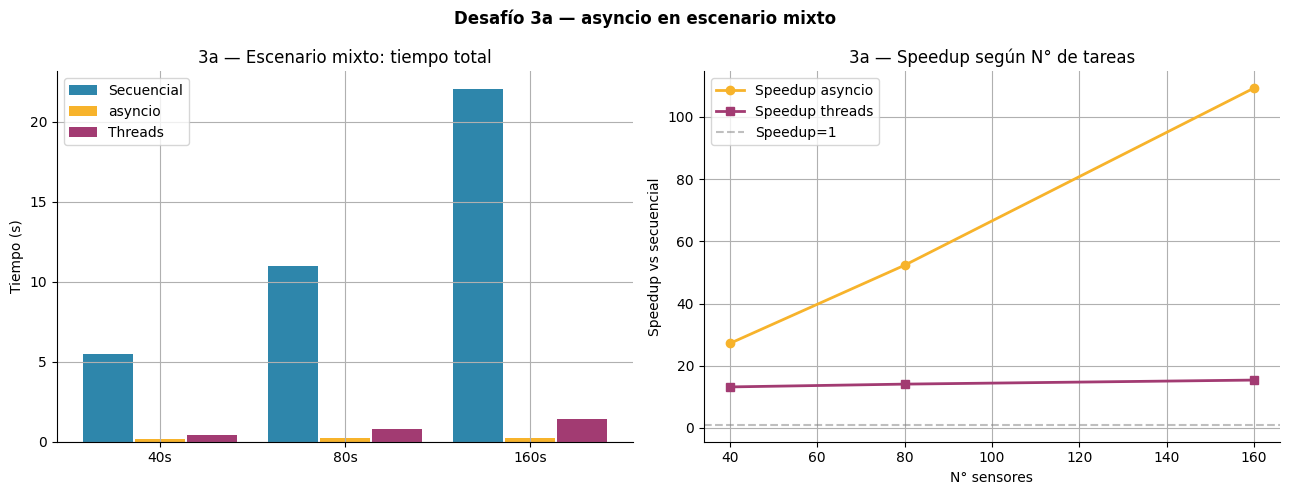

In [14]:
# ── Gráfico 3a ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x3 = range(len(sizes_3))
vals_s = [float(f[1]) for f in filas_3a]
vals_a = [float(f[2]) for f in filas_3a]
vals_t = [float(f[3]) for f in filas_3a]

# Barras de tiempo
axes[0].bar([i-0.28 for i in x3], vals_s, 0.27, label="Secuencial", color="#2E86AB")
axes[0].bar([i+0.00 for i in x3], vals_a, 0.27, label="asyncio",    color="#F7B32B")
axes[0].bar([i+0.28 for i in x3], vals_t, 0.27, label="Threads",    color="#A23B72")
axes[0].set_xticks(list(x3)); axes[0].set_xticklabels([f"{n}s" for n in sizes_3])
axes[0].set_ylabel("Tiempo (s)")
axes[0].set_title("3a — Escenario mixto: tiempo total")
axes[0].legend()

# Speedup
sp_a = [float(f[4][:-1]) for f in filas_3a]
sp_t = [float(f[5][:-1]) for f in filas_3a]
axes[1].plot(sizes_3, sp_a, "o-", color="#F7B32B", label="Speedup asyncio",  linewidth=2)
axes[1].plot(sizes_3, sp_t, "s-", color="#A23B72", label="Speedup threads",  linewidth=2)
axes[1].axhline(1, linestyle="--", color="gray", alpha=0.5, label="Speedup=1")
axes[1].set_xlabel("N° sensores")
axes[1].set_ylabel("Speedup vs secuencial")
axes[1].set_title("3a — Speedup según N° de tareas")
axes[1].legend()

plt.suptitle("Desafío 3a — asyncio en escenario mixto", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG_DIR / "fig_3a.png"), dpi=120)
plt.show()


#### Análisis técnico ejercicio 3a:

Se demuestra la eficiencia de la programación asincrónica aplicada a tareas de entrada y salida mediante un modelo de multitarea cooperativa. A diferencia de los enfoques basados en hilos o procesos, asyncio opera sobre un único hilo de ejecución utilizando un bucle de eventos (event loop) para gestionar la concurrencia. Esta arquitectura elimina por completo el overhead asociado a la creación de múltiples pilas de memoria y la intervención del sistema operativo en los cambios de contexto. Al ceder el control del procesador de forma voluntaria durante las esperas de I/O, el sistema logra una densidad de tareas mucho mayor con un consumo de recursos significativamente menor.

Los resultados obtenidos validan que la asincronía es la estrategia más escalable para mitigar latencias externas sin incurrir en las limitaciones del Global Interpreter Lock (GIL). Mientras que el uso de hilos requiere una gestión compleja de cerrojos y el multiprocesamiento implica una costosa duplicación del intérprete, el modelo asincrónico optimiza el uso de la CPU al mantenerla activa solo para la lógica de orquestación. En conclusión, este ejercicio confirma que, para entornos de alta concurrencia donde el cuello de botella es la espera de recursos externos, asyncio representa la solución más eficiente al ofrecer un paralelismo lógico ligero que maximiza el rendimiento global de la aplicación.


### 3b) Recomendación técnica final

Antes de elegir cualquier estrategia de concurrencia en Python, lo primero que hay que preguntarse es qué está haciendo realmente el programa mientras corre: ¿está calculando, o está esperando? Esa distinción, que parece obvia, fue la que más claramente se manifestó en los experimentos y termina siendo el criterio más importante.

Para tareas donde el procesador trabaja sin parar, usar hilos no solo no ayuda, sino que puede empeorar las cosas. En el experimento 1a lo vimos directamente: el ratio fue de 1.086x, es decir, la versión con hilos fue más lenta que la secuencial. Esto se explica por el GIL, que obliga a los hilos a turnarse para ejecutar bytecode. Si la tarea es cómputo puro, ese turno nunca llega realmente a aprovechar los núcleos del procesador. En ese caso, la única alternativa que funcionó fue el multiprocesamiento, que en el experimento 2a logró hasta 1.66x de aceleración porque cada proceso corre con su propio intérprete.

Sin embargo, tampoco es tan simple tomar esta desición. El tamaño de cada tarea importa mucho. Lanzar un pool de procesos tiene un costo de arranque real y si el trabajo por unidad es pequeño, ese overhead se come cualquier ganancia. En los experimentos, la criba funcionó bien con procesos porque cada N era suficientemente grande. Con tareas más chicas, los procesos habrían perdido frente al secuencial.

Para I/O, la situación cambia completamente. En el experimento 1b, los hilos lograron un speedup de 3.87x simplemente porque el GIL se libera durante las llamadas al sistema de archivos. Ahí los hilos son simples de implementar y funcionan bien. Pero cuando la escala crece, asyncio se convierte en la opción más eficiente. Los números del experimento 3a son bastante elocuentes: con 160 sensores, los hilos dieron 15.4x y asyncio dio 109.2x, operando con un solo hilo y sin los cambios de contexto del sistema operativo.

Una advertencia que vale la pena mencionar: esos speedups tan altos de asyncio se obtuvieron con latencias simuladas de 80 a 200 ms. En condiciones reales los números pueden ser muy distintos. No conviene diseñar una arquitectura basándose solo en benchmarks con time.sleep.